# ANFIS Genérico do Zero para Regressão e Classificação

Este notebook apresenta uma implementação ANFIS totalmente genérica, capaz de lidar com qualquer número de entradas e regras (funções de pertinência), tanto para regressão quanto para classificação (binária e multiclasse).

- Forward pass e treinamento genéricos
- Inicialização automática dos parâmetros
- Exemplo de uso para regressão e classificação

In [1]:
import numpy as np
from itertools import product
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelBinarizer

# Função de pertinência Gaussiana
def gaussmf(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# Gera todas as combinações de regras possíveis
def all_rule_combinations(n_inputs, n_mfs):
    return np.array(list(product(*[range(n_mfs) for _ in range(n_inputs)])))

# Forward pass genérico
def anfis_forward(X, mf_params, cons_params):
    n_samples, n_inputs = X.shape
    n_mfs = mf_params['mean'].shape[1]
    rules = all_rule_combinations(n_inputs, n_mfs)
    n_rules = rules.shape[0]
    # Camada 1: Fuzzificação
    mu = np.zeros((n_samples, n_inputs, n_mfs))
    for i in range(n_inputs):
        for j in range(n_mfs):
            mu[:, i, j] = gaussmf(X[:, i], mf_params['mean'][i, j], mf_params['sigma'][i, j])
    # Camada 2: firing strength de cada regra
    w = np.ones((n_samples, n_rules))
    for r, rule in enumerate(rules):
        for i in range(n_inputs):
            w[:, r] *= mu[:, i, rule[i]]
    # Camada 3: Normalização
    w_sum = np.sum(w, axis=1, keepdims=True) + 1e-8
    w_norm = w / w_sum
    # Camada 4: Consequente (linear)
    f = np.dot(X, cons_params['p'].T) + cons_params['r']  # shape: (n_samples, n_rules)
    # Camada 5: Saída
    y = np.sum(w_norm * f, axis=1)
    return y

# Inicialização automática dos parâmetros
def init_params(X, n_mfs):
    n_inputs = X.shape[1]
    n_rules = n_mfs ** n_inputs
    mf_means = np.zeros((n_inputs, n_mfs))
    mf_sigmas = np.zeros((n_inputs, n_mfs))
    for i in range(n_inputs):
        percentiles = np.linspace(0, 100, n_mfs+2)[1:-1]
        mf_means[i] = np.percentile(X[:,i], percentiles)
        mf_sigmas[i] = (np.max(X[:,i]) - np.min(X[:,i]))/(2*n_mfs)
    mf_params = {'mean': mf_means, 'sigma': mf_sigmas}
    cons_params = {'p': np.random.randn(n_rules, n_inputs)*0.1, 'r': np.random.randn(n_rules)*0.1}
    return mf_params, cons_params

# Treinamento via gradiente numérico (didático)
def train_anfis(X, y, mf_params, cons_params, lr=0.001, epochs=20, delta=1e-3):
    mf_params = {k: v.copy() for k, v in mf_params.items()}
    cons_params = {k: v.copy() for k, v in cons_params.items()}
    errors = []
    for epoch in range(epochs):
        y_pred = anfis_forward(X, mf_params, cons_params)
        error = y_pred - y
        mse = np.mean(error**2)
        errors.append(mse)
        # Gradientes numéricos (mais estável)
        for key in mf_params:
            arr = mf_params[key]
            for idx, _ in np.ndenumerate(arr):
                orig = arr[idx]
                arr[idx] = orig + delta
                y_pred2 = anfis_forward(X, mf_params, cons_params)
                grad = (np.mean((y_pred2 - y)**2) - mse) / delta
                arr[idx] = orig - lr * grad
                arr[idx] = np.clip(arr[idx], -10, 10)
        for key in cons_params:
            arr = cons_params[key]
            for idx, _ in np.ndenumerate(arr):
                orig = arr[idx]
                arr[idx] = orig + delta
                y_pred2 = anfis_forward(X, mf_params, cons_params)
                grad = (np.mean((y_pred2 - y)**2) - mse) / delta
                arr[idx] = orig - lr * grad
                arr[idx] = np.clip(arr[idx], -10, 10)
    return mf_params, cons_params, errors

# Função para classificação multiclasse (One-vs-Rest)
def train_anfis_multiclass(X, y, n_mfs=2, epochs=10, lr=0.01):
    lb = LabelBinarizer()
    Y_bin = lb.fit_transform(y)
    if Y_bin.ndim == 1:
        Y_bin = Y_bin.reshape(-1, 1)
    if Y_bin.shape[1] == 1:
        Y_bin = np.hstack([1-Y_bin, Y_bin])
    models = []
    for i in range(Y_bin.shape[1]):
        mf_params, cons_params = init_params(X, n_mfs)
        mf_params_tr, cons_params_tr, errors = train_anfis(X, Y_bin[:,i], mf_params, cons_params, lr=lr, epochs=epochs)
        models.append((mf_params_tr, cons_params_tr))
    return models, lb

def anfis_predict_multiclass(X, models, lb):
    probas = []
    for mf_params, cons_params in models:
        probas.append(anfis_forward(X, mf_params, cons_params))
    probas = np.column_stack(probas)  # Sempre 2D: (n_amostras, n_classes)
    y_pred = np.argmax(probas, axis=1)
    # Retorna os rótulos originais usando os índices das classes
    return lb.classes_[y_pred]

# ===================== EXEMPLOS DE USO =====================

# Regressão
print("=== Regressão ===")
dim = 3
n_mfs = 2
np.random.seed(0)
X = np.random.uniform(0, 10, (200, dim))
y = X[:,0] - 2*X[:,1] + 0.5*X[:,2] + np.random.normal(0, 1, 200)
mf_params, cons_params = init_params(X, n_mfs)
mf_params_tr, cons_params_tr, errors = train_anfis(X, y, mf_params, cons_params, lr=0.0000001, epochs=200)
y_pred = anfis_forward(X, mf_params_tr, cons_params_tr)
print('MSE final (regressão):', np.mean((y_pred-y)**2))

# Classificação binária
print("\n=== Classificação Binária ===")
Xb = np.random.uniform(0, 10, (200, dim))
yb = (Xb[:,0] + Xb[:,1] - Xb[:,2] > 10).astype(float)
mf_params, cons_params = init_params(Xb, n_mfs)
mf_params_tr, cons_params_tr, errors = train_anfis(Xb, yb, mf_params, cons_params, lr=0.0000001, epochs=200)
yb_pred = anfis_forward(Xb, mf_params_tr, cons_params_tr)
yb_pred_class = (yb_pred > 0.5).astype(int)
print('Acurácia binária:', accuracy_score(yb, yb_pred_class))
print('Matriz de confusão:\n', confusion_matrix(yb, yb_pred_class))

# Classificação multiclasse
print("\n=== Classificação Multiclasse ===")
np.random.seed(42)
Xc = np.random.uniform(0, 10, (300, 3))
yc = np.random.choice([0,1,2], size=300)  # 3 classes
models, lb = train_anfis_multiclass(Xc, yc, n_mfs=2, epochs=200, lr=0.00001)
yc_pred = anfis_predict_multiclass(Xc, models, lb)
print('Acurácia multiclasse:', accuracy_score(yc, yc_pred))
print('Matriz de confusão:\n', confusion_matrix(yc, yc_pred))

=== Regressão ===
MSE final (regressão): 60.69041702288288

=== Classificação Binária ===
Acurácia binária: 0.755
Matriz de confusão:
 [[114  47]
 [  2  37]]

=== Classificação Multiclasse ===
Acurácia multiclasse: 0.29333333333333333
Matriz de confusão:
 [[25 47 33]
 [34 36 30]
 [38 30 27]]


In [2]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, cohen_kappa_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.svm import SVR, SVC
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils import resample
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os


warnings.filterwarnings('ignore')



# Garante que a pasta 'graficos' existe
os.makedirs('graficos', exist_ok=True)

In [3]:
# Carregando os datasets
import pandas as pd
energy = pd.read_csv('datasets_salvos/energy_efficiency.csv')
california = pd.read_csv('datasets_salvos/california_housing.csv')
wine = pd.read_csv('datasets_salvos/winequality_red.csv')
iris = pd.read_csv('datasets_salvos/iris.csv')
print('Energy Efficiency Dataset:')
display(energy.head())
print('California Housing Dataset:')
display(california.head())
print('Wine Quality Red Dataset:')
display(wine.head())
print('Iris Dataset:')
display(iris.head())

Energy Efficiency Dataset:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


California Housing Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Wine Quality Red Dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Funções de pré-processamento
def preprocess_regression(df, target_cols):
    df = df.dropna()
    X = df.drop(columns=target_cols)
    y = df[target_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y

def preprocess_classification(df, target_col, balance=False):
    print(f'Tamanho do DataFrame antes do dropna: {df.shape}')
    df = df.dropna()
    print(f'Tamanho do DataFrame após o dropna e antes do balanceamento: {df.shape}')
    X = df.drop(columns=[target_col])
    y = df[target_col]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    if balance:
        # Concatena X e y para facilitar o balanceamento
        data = np.hstack((X_scaled, y.values.reshape(-1, 1)))
        classes = np.unique(y)
        max_count = max([np.sum(y == c) for c in classes])
        balanced = []
        for c in classes:
            class_data = data[y == c]
            class_upsampled = resample(class_data, replace=True, n_samples=max_count, random_state=42)
            balanced.append(class_upsampled)
        data_balanced = np.vstack(balanced)
        np.random.shuffle(data_balanced)
        X_scaled = data_balanced[:, :-1]
        y = data_balanced[:, -1]
        print(f'Tamanho do DataFrame após o balanceamento : {X_scaled.shape}')
    return X_scaled, y
# Pré-processamento
X_energy, y_energy = preprocess_regression(energy, ['Y1', 'Y2'])
X_california, y_california = preprocess_regression(california, ['MedHouseVal'])
X_wine, y_wine = preprocess_classification(wine, 'quality', balance= False)  
X_iris, y_iris = preprocess_classification(iris, 'target', balance=False) 
X_wine_b, y_wine_b = preprocess_classification(wine, 'quality', balance=True)  
X_iris_b, y_iris_b = preprocess_classification(iris, 'target', balance=True)   

Tamanho do DataFrame antes do dropna: (1599, 12)
Tamanho do DataFrame após o dropna e antes do balanceamento: (1599, 12)
Tamanho do DataFrame antes do dropna: (150, 5)
Tamanho do DataFrame após o dropna e antes do balanceamento: (150, 5)
Tamanho do DataFrame antes do dropna: (1599, 12)
Tamanho do DataFrame após o dropna e antes do balanceamento: (1599, 12)
Tamanho do DataFrame após o balanceamento : (4086, 11)
Tamanho do DataFrame antes do dropna: (150, 5)
Tamanho do DataFrame após o dropna e antes do balanceamento: (150, 5)
Tamanho do DataFrame após o balanceamento : (150, 4)


In [5]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, cohen_kappa_score

warnings.filterwarnings('ignore')
os.makedirs('graficos', exist_ok=True)

# Carregando os datasets
energy = pd.read_csv('datasets_salvos/energy_efficiency.csv')
california = pd.read_csv('datasets_salvos/california_housing.csv')
wine = pd.read_csv('datasets_salvos/winequality_red.csv')
iris = pd.read_csv('datasets_salvos/iris.csv')

print('Energy Efficiency Dataset:')
display(energy.head())
print('California Housing Dataset:')
display(california.head())
print('Wine Quality Red Dataset:')
display(wine.head())
print('Iris Dataset:')
display(iris.head())

# Funções de pré-processamento
def preprocess_regression(df, target_cols):
    df = df.dropna()
    X = df.drop(columns=target_cols)
    y = df[target_cols].values.squeeze()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y

def preprocess_classification(df, target_col, balance=False, verbose=False):
    df = df.dropna()
    X = df.drop(columns=[target_col])
    y = df[target_col].values
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    if balance:
        data = np.hstack((X_scaled, y.reshape(-1, 1)))
        classes = np.unique(y)
        max_count = max([np.sum(y == c) for c in classes])
        balanced = []
        for c in classes:
            class_data = data[y == c]
            class_upsampled = resample(class_data, replace=True, n_samples=max_count, random_state=42)
            balanced.append(class_upsampled)
        data_balanced = np.vstack(balanced)
        np.random.shuffle(data_balanced)
        X_scaled = data_balanced[:, :-1]
        y = data_balanced[:, -1]
        if verbose:
            print(f'Tamanho do DataFrame após o balanceamento : {X_scaled.shape}')
    return X_scaled, y

# Funções de métrica e plot
def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def classification_metrics(y_true, y_pred):
    return {
        'Acuracia': accuracy_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred, average='weighted'),
        'Kappa': cohen_kappa_score(y_true, y_pred)
    }

def plot_confusion_matrix(y_true, y_pred, title='Matriz de Confusão', filename=None):
    plt.figure(figsize=(6,6))
    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap=plt.cm.Blues, normalize='true')
    plt.title(f"{title} (Porcentagem)")
    for text in disp.text_.ravel():
        val = float(text.get_text())
        text.set_text(f"{val*100:.1f}%")
    if filename:
        plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()

def plot_regression_scatter(y_true, y_pred, title='Dispersão - Regressão', filename=None):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Previsto')
    plt.title(title)
    plt.grid(True)
    if filename:
        plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()


Energy Efficiency Dataset:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


California Housing Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Wine Quality Red Dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Energy Efficiency - Métricas: {'RMSE': 21.91108787967998, 'MAE': 17.606097161018262, 'R2': -3.721650602758758}


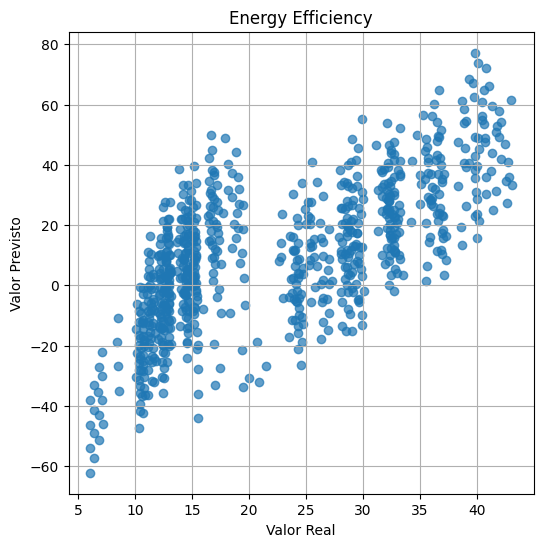

In [6]:

# ===================== EXEMPLOS DE USO =====================

# Regressão com Energy Efficiency
X_energy, y_energy = preprocess_regression(energy, ['Y1'])
mf_params, cons_params = init_params(X_energy, n_mfs=2)
mf_params_tr, cons_params_tr, errors = train_anfis(X_energy, y_energy, mf_params, cons_params, lr=0.001, epochs=5)
y_pred = anfis_forward(X_energy, mf_params_tr, cons_params_tr)
print('Energy Efficiency - Métricas:', regression_metrics(y_energy, y_pred))
plot_regression_scatter(y_energy, y_pred, title='Energy Efficiency', filename='energy_efficiency_y1_anfis')


Energy Efficiency - Métricas (Y2): {'RMSE': 24.175270753838223, 'MAE': 19.320251262949757, 'R2': -5.466148241873051}


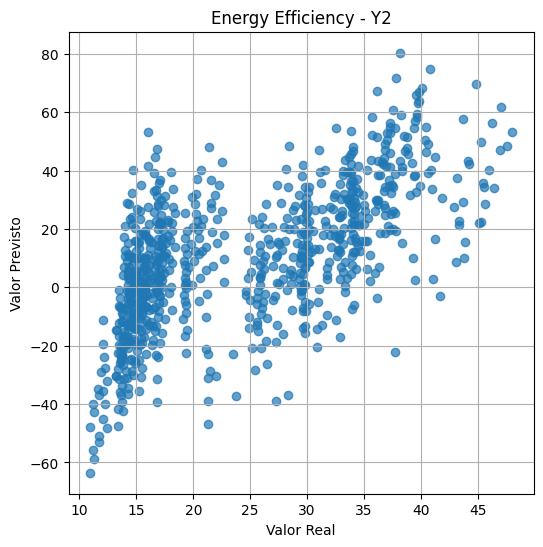

In [7]:
# Regressão com Energy Efficiency - Y2
X_energy, y_energy2 = preprocess_regression(energy, ['Y2'])
mf_params, cons_params = init_params(X_energy, n_mfs=2)
mf_params_tr, cons_params_tr, errors = train_anfis(X_energy, y_energy2, mf_params, cons_params, lr=0.001, epochs=5)
y_pred = anfis_forward(X_energy, mf_params_tr, cons_params_tr)
print('Energy Efficiency - Métricas (Y2):', regression_metrics(y_energy2, y_pred))
plot_regression_scatter(y_energy2, y_pred, title='Energy Efficiency - Y2', filename='energy_efficiency_y2_anfis')

California Housing - Métricas: {'RMSE': 2.3141297681859867, 'MAE': 2.0082556964942695, 'R2': -3.021775657799421}


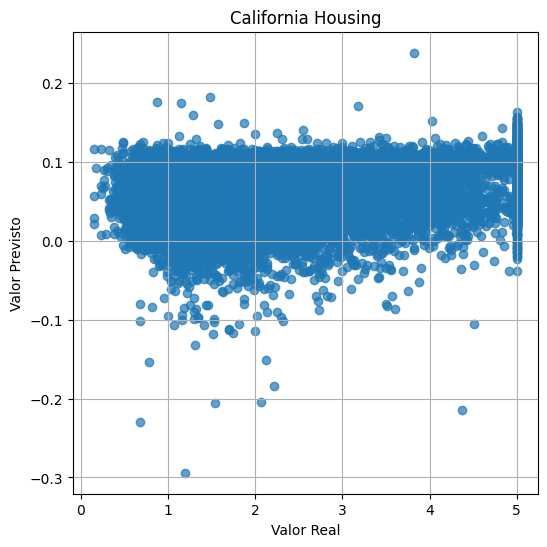

In [8]:
# ===================== EXEMPLOS DE USO =====================

# Regressão com California Housing
X_california, y_california = preprocess_regression(california, ['MedHouseVal'])
mf_params, cons_params = init_params(X_california, n_mfs=2)
mf_params_tr, cons_params_tr, errors = train_anfis(X_california, y_california, mf_params, cons_params, lr=0.001, epochs=5)
y_pred = anfis_forward(X_california, mf_params_tr, cons_params_tr)
print('California Housing - Métricas:', regression_metrics(y_california, y_pred))
plot_regression_scatter(y_california, y_pred, title='California Housing', filename='california_housing_anfis')

In [ ]:

# Classificação Multiclasse com Wine Quality (balanceado e não balanceado)
for balance in [False, True]:
    print(f"\nWine Quality - Dados balanceados: {balance}")
    X_wine, y_wine = preprocess_classification(wine, 'quality', balance=balance)
    models, lb = train_anfis_multiclass(X_wine, y_wine, n_mfs=2, epochs=5, lr=0.001)
    y_pred = anfis_predict_multiclass(X_wine, models, lb)
    print('Wine Quality - Métricas:', classification_metrics(y_wine, y_pred))
    plot_confusion_matrix(y_wine, y_pred, title=f'Wine Quality (balance={balance})', filename=f'wine_quality_balance_{balance}')



Wine Quality - Dados balanceados: False


In [ ]:

# Classificação Multiclasse com Iris (balanceado e não balanceado)
for balance in [False, True]:
    print(f"\nIris - Dados balanceados: {balance}")
    X_iris, y_iris = preprocess_classification(iris, 'target', balance=balance)
    models, lb = train_anfis_multiclass(X_iris, y_iris, n_mfs=2, epochs=5, lr=0.001)
    y_pred = anfis_predict_multiclass(X_iris, models, lb)
    print('Iris - Métricas:', classification_metrics(y_iris, y_pred))
    plot_confusion_matrix(y_iris, y_pred, title=f'Iris (balance={balance})', filename=f'iris_balance_{balance}')
